# Clasificación de Dígitos Manuscritos con MNIST

## Pipeline de Entrenamiento, Comparación y Selección de Modelos

**Problema:** Clasificación multiclase de imágenes manuscritas de dígitos del 0 al 9.
Cada imagen es de 28×28 píxeles en escala de grises (784 valores de entrada) y la salida
es una clase entre 10 posibles.

**Objetivo del notebook:** Diseñar un pipeline de entrenamiento reproducible, justificable
y exportable para ser consumido desde una API. La selección del modelo no se realiza por
intuición ni preferencia personal, sino mediante una comparación controlada entre familias
de modelos con distintos supuestos inductivos, siguiendo un protocolo consistente de
entrenamiento y validación.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(keras.__version__)

3.14.1


## 1. Carga del Dataset

Se utiliza el dataset MNIST incluido en Keras. Está dividido en 60 000 imágenes
de entrenamiento y 10 000 de prueba, con etiquetas del 0 al 9.

In [3]:
(x_train_all, y_train_all), (x_test, y_test) = keras.datasets.mnist.load_data()
#Entrenamiento = %85.7 del total, Prueba = %14.3 del total

print(f"Dimensiones de entrenamiento - Imagenes:    {x_train_all.shape}")
print(f"Dimensiones de entrenamiento - Etiquetas:   {y_train_all.shape}")
print(f"Dimensiones de prueba - imagenes:           {x_test.shape}")
print(f"Dimensiones de prueba - Etiquetas:          {y_test.shape}")
print(f"Rangos de valores de los pixeles de prueba: [{x_test.min()}, {x_test.max()}]")
print(f"Categorias:                                 {np.unique(y_train_all)}")

Dimensiones de entrenamiento - Imagenes:    (60000, 28, 28)
Dimensiones de entrenamiento - Etiquetas:   (60000,)
Dimensiones de prueba - imagenes:           (10000, 28, 28)
Dimensiones de prueba - Etiquetas:          (10000,)
Rangos de valores de los pixeles de prueba: [0, 255]
Categorias:                                 [0 1 2 3 4 5 6 7 8 9]


## 2. Analisis Exploratorio

MNIST es un dataset estandarizado y limpio, por lo que el análisis exploratorio se
limita a verificar:

- **Balance de clases** — confirmar que no hay desbalance significativo.
- **Visualización de ejemplos** — contextualizar el aspecto de los datos.
- **Forma y rango de píxeles** — guiar el preprocesamiento.

Al ser un problema de visión ya preprocesado por diseño, no se requiere limpieza
compleja (imputación, outliers, normalización de variables heterogéneas).

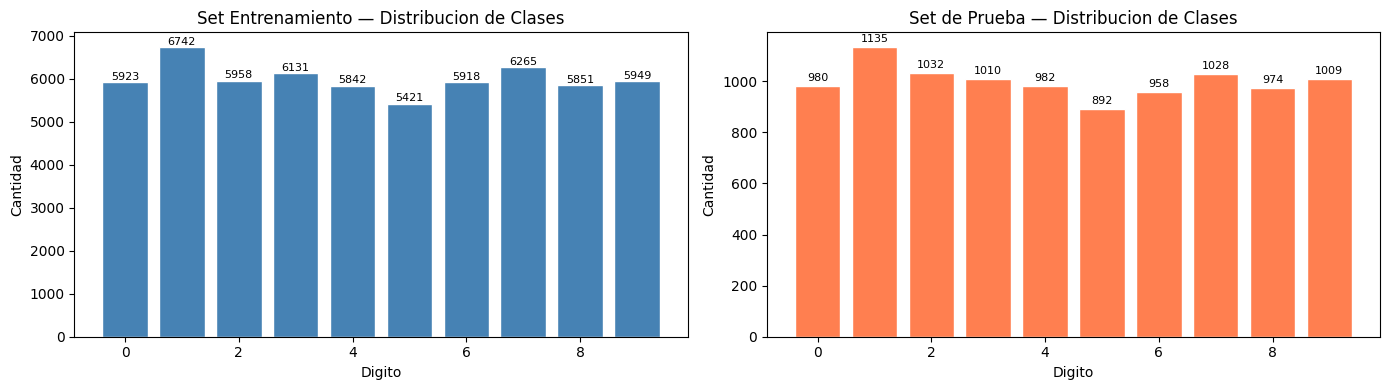

ratio de entrenamiento (max/min): 1.24
ratio de prueba (max/min):  1.27
-> Clases razonablemente balanceadas en ambos conjuntos.


In [4]:
# Distribucion de Clases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

train_counts = np.bincount(y_train_all)
test_counts = np.bincount(y_test)

ax1.bar(range(10), train_counts, color='steelblue', edgecolor='white')
ax1.set_title('Set Entrenamiento — Distribucion de Clases')
ax1.set_xlabel('Digito'); ax1.set_ylabel('Cantidad')
for i, v in enumerate(train_counts):
    ax1.text(i, v + 50, str(v), ha='center', fontsize=8)

ax2.bar(range(10), test_counts, color='coral', edgecolor='white')
ax2.set_title('Set de Prueba — Distribucion de Clases')
ax2.set_xlabel('Digito'); ax2.set_ylabel('Cantidad')
for i, v in enumerate(test_counts):
    ax2.text(i, v + 20, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

ratio_train = train_counts.max() / train_counts.min()
ratio_test = test_counts.max() / test_counts.min()
print(f"ratio de entrenamiento (max/min): {ratio_train:.2f}")
print(f"ratio de prueba (max/min):  {ratio_test:.2f}")
print("-> Clases razonablemente balanceadas en ambos conjuntos.")

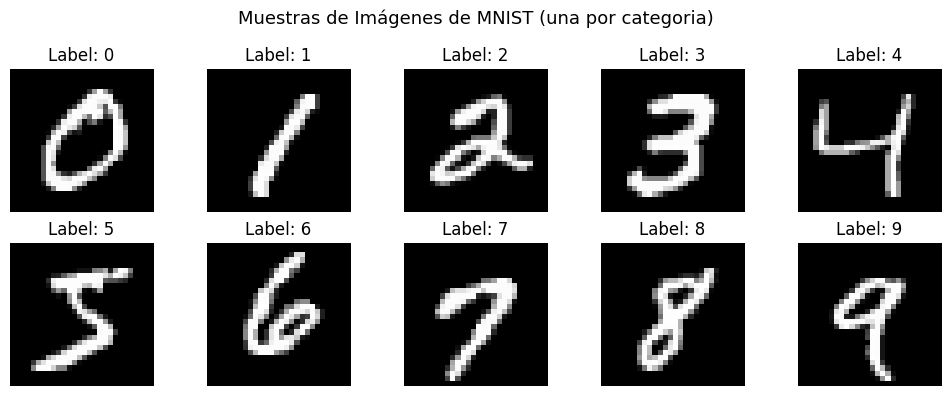

In [5]:
# Visualizar un ejemplo por categoria
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()
# print(y_train_all[20])
for digit in range(10):
    idx = np.where(y_train_all == digit)[0][0]
    # print(x_train_all[idx])
    axes[digit].imshow(x_train_all[idx], cmap='gray')
    axes[digit].set_title(f'Label: {digit}')
    axes[digit].axis('off')
plt.suptitle('Muestras de Imágenes de MNIST (una por categoria)', fontsize=13)
plt.tight_layout()
plt.show()

### Analisis para aplicacion de SMOTE y técnicas de sobremuestreo


No se aplica SMOTE ni ninguna técnica de sobremuestreo sintético por las siguientes razones:

1. **Balance natural:** MNIST presenta una distribución casi uniforme (~10 % por clase).  
   El ratio max/min es inferior a 2, muy por debajo del umbral en que el desbalance
   se considera problemático (< 10:1).

2. **Naturaleza de los datos:** SMOTE interpola entre vecinos en el espacio de características.
   En imágenes, esto equivale a promediar píxeles entre dos dígitos reales, generando
   ejemplos sintéticos que no corresponden a dígitos manuscritos realistas. Esto puede
   introducir ruido sin aportar información discriminativa útil.

3. **Suficiencia de datos:** Con 60 000 muestras de entrenamiento, el volumen es
   más que suficiente para que los modelos aprendan patrones que sean generalizables.

## 3. Preprocesamiento

### Normalización

Los valores de píxel (0–255) se escalan al rango [0, 1] dividiendo entre 255.0.
Esto mejora la estabilidad numérica y facilita la convergencia del optimizador,
especialmente en redes neuronales.

### Representación de entrada según el modelo

- **Modelos clásicos (Regresión Logística) y MLP:** las imágenes se *aplanan* a un
  vector de 784 características. Esto es necesario porque estos modelos operan sobre
  vectores de características independientes; no pueden explotar la estructura 2D.

- **CNN:** se conserva la forma espacial (28, 28) y se añade una dimensión de canal
  (1 para escala de grises), dando (28, 28, 1). Las capas convolucionales preservan
  la topología de la imagen y aprenden patrones locales (bordes, trazos, esquinas)
  de forma traslacionalmente invariante.

In [6]:
# Normalizar el valo de los pixeles entre 0 y 1
x_train_all_norm = x_train_all.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
print(x_train_all_norm.shape, x_test_norm.shape)


# Conversion de las imagenes a formato plano (784,) para modelos clásicos
x_train_all_flat = x_train_all_norm.reshape(len(x_train_all_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)
print(f"Nuevo formato Entrenamiento: {x_train_all_flat.shape}")
print(f"Nuevo formato Prueba:  {x_test_flat.shape}")

(60000, 28, 28) (10000, 28, 28)
Nuevo formato Entrenamiento: (60000, 784)
Nuevo formato Prueba:  (10000, 784)


## 4. Metodología de Selección de Modelos

Para la seleccion del modelo se decide realizar una comparacion o evaluacion entre varios modelos que no se escogen de forma aleatoria,
por el contrario se comparan **tres familias** que aunque son distintas, nos pueden ayudar a resolver el problema y despues escoger la que generalice mejor

| Familia | Supuesto | Rol en la comparación |
|---------|----------|----------------------|
| **Regresión Logística** (multiclase) | Los dígitos son separables linealmente en el espacio de píxeles aplanado | **Linea de Partida** Modelo como referencia. Con este identificamos los demas modelos cuanto mejoran o empeoran. |
| **MLP** (Perceptrón Multicapa) | Puede aprender relaciones más complejas entre los píxeles que un modelo simple no logra captar. | **Complejidad intermedia.** Es más flexible que la regresión logística. |
| **CNN** (Red Convolucional) | La información está en los patrones locales y su disposición espacial | **Candidato más fuerte.** Aprovecha mejor la estructura de la imagen, por lo que suele ser la opción más adecuada en este tipo de problema convolucionales. |

Aunque se tiene una idea puntual de cual seria el resultado esperado lo mejor es realizar un analisis con modelos para identificar su generalizacion al problema en especifico.

### Modelos descartados y por qué

No se incluyen árboles de decisión, Random Forest, Naive Bayes ni KNN porque:

- **Árboles/Random Forest:** Trabajan sobre características tabulares independientes.
  En píxeles de imagen, las relaciones espaciales importan; un árbol no puede
  capturar que un píxel en (10, 10) está relacionado con su vecino en (10, 11).
- **Naive Bayes:** Asume independencia condicional de las características, lo cual
  es claramente falso para píxeles adyacentes (altamente correlacionados).


### Control de data leakage

El conjunto de **test (10 000 muestras) se mantiene completamente aislado** hasta la
evaluación final del modelo seleccionado. Durante el desarrollo se utiliza únicamente
el conjunto de entrenamiento original (60 000), subdividido internamente en:

- **Entrenamiento y validación** para modelos de deep learning (80/20 estratificado).
- **Validación cruzada estratificada (5 folds)** para Regresión Logística.

Esto garantiza que ninguna decisión de modelo o hiperparámetro se contamine con
información del conjunto de prueba.

In [7]:
# Estratificar los modelos clásicos (Logistic Regression, MLP) con un split 80/20 del set de entrenamiento
# Deacurdo a la documentación de sklearn, para mantiene la proporción de clases en ambos conjuntos.
x_train_dl, x_val_dl, y_train_dl, y_val_dl = train_test_split( x_train_all_flat, y_train_all, test_size=0.2, random_state=SEED, stratify=y_train_all)

# 2D versiones para entrenamiento de CNN reasignacion de dimensiones (28, 28, 1)
x_train_dl_2d = x_train_dl.reshape(-1, 28, 28, 1)
x_val_dl_2d = x_val_dl.reshape(-1, 28, 28, 1)

print(f"Set de entrenamiento para modelos clasicos: {x_train_dl.shape}  | Set entrenamiento de validacion:  {x_val_dl.shape}")
print(f"Set de entrenamiento para modelos 2D:   {x_train_dl_2d.shape} | Set de validacion 2D:   {x_val_dl_2d.shape}")

Set de entrenamiento para modelos clasicos: (48000, 784)  | Set entrenamiento de validacion:  (12000, 784)
Set de entrenamiento para modelos 2D:   (48000, 28, 28, 1) | Set de validacion 2D:   (12000, 28, 28, 1)


## 5. Regresión Logística Multiclase

Es tomar una linea para tomar como base ¿De forma Lineal podemos atacar el problema?

Se utiliza **GridSearchCV** con **StratifiedKFold (k=3)** sobre el conjunto de
entrenamiento completo, buscando el parámetro de regularización `C` y el solver.
No se intenta buscar el hiper parametro perfecto, solo la solucion conservadora o robusta (la vieja confiable)
para atacar el problema.

Regularizacion: 'C': [0.1, 1, 10]

In [8]:
param_grid = {
    'C': [0.1, 1, 10], 
    'solver': ['lbfgs'],
    'max_iter': [1000, 2000]
}

lr_base = LogisticRegression(
    random_state=SEED, n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
grid_lr = GridSearchCV(
    lr_base, param_grid,
    cv=cv, scoring='accuracy',
    verbose=0
)

t0 = time()
grid_lr.fit(x_train_all_flat, y_train_all)
t_lr = time() - t0

print(f"\n Regresión Logística — Tiempo: {t_lr:.1f}s")
print(f"   Mayor CV Precision:  {grid_lr.best_score_:.4f}")
print(f"   Parametros con mejor desempeño:   {grid_lr.best_params_}")

c:\PruebaTec_BdB\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\PruebaTec_BdB\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\PruebaTec_BdB\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\PruebaTec_BdB\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m


 Regresión Logística — Tiempo: 164.1s
   Mayor CV Precision:  0.9205
   Parametros con mejor desempeño:   {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}


In [9]:
# Mostrar los resultados
results_lr = pd.DataFrame(grid_lr.cv_results_)
top_lr = results_lr.sort_values('rank_test_score')
top_lr

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,4.665124,0.136956,0.029467,0.001192,0.1,1000,lbfgs,"{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.92215,0.92105,0.91830,0.920500,0.001619,1
1,4.468507,0.714540,0.028344,0.000459,0.1,2000,lbfgs,"{'C': 0.1, 'max_iter': 2000, 'solver': 'lbfgs'}",0.92215,0.92105,0.91830,0.920500,0.001619,1
2,7.683005,0.286568,0.028224,0.000670,1.0,1000,lbfgs,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.92040,0.91845,0.91755,0.918800,0.001190,3
3,7.706738,0.290271,0.028274,0.000200,1.0,2000,lbfgs,"{'C': 1, 'max_iter': 2000, 'solver': 'lbfgs'}",0.92040,0.91845,0.91755,0.918800,0.001190,3
4,13.970482,0.607581,0.028832,0.000296,10.0,1000,lbfgs,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.91490,0.91320,0.91245,0.913517,0.001025,5
5,13.759325,0.489695,0.029658,0.000973,10.0,2000,lbfgs,"{'C': 10, 'max_iter': 2000, 'solver': 'lbfgs'}",0.91490,0.91320,0.91245,0.913517,0.001025,5


## 6. MLP (Perceptrón Multicapa)

La idea de incluir a Modelos **no lineales** es cambiar un poco el enfoque
permitiendo capturar relaciones entre píxeles. pero con cierta desventaja
esto debido a que el vector no esta 28 x 28 si no que esta aplanado es decir estan
los 784 valores del pixel claramente normalizados por lo que **pierde la estructura espacial**
de la imagen.

Se prueba un número reducido de configuraciones:
- Arquitectura de 1 capa oculta (128 neuronas) vs. 2 capas ocultas (256 -> 128).
- Learning rate de 0.001 y 0.0005.
- Dropout (0.3) como regularización.

Se entrena con **EarlyStopping** (paciencia 5 épocas) sobre pérdida de validación
para evitar sobreajuste, restaurando los mejores pesos.

In [10]:
def build_mlp(hidden_units, dropout_rate=0.3, lr=0.001):
    model = models.Sequential(name='MLP')
    model.add(layers.Input(shape=(784,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_configs = [
    {'hidden': [128],       'lr': 0.001, 'bs': 64, 'label': 'MLP-128-lr0-001'},
    {'hidden': [128],       'lr': 0.0005,'bs': 64, 'label': 'MLP-128-lr0-0005'},
    {'hidden': [256, 128],  'lr': 0.001, 'bs': 64, 'label': 'MLP-256-128-lr0-001'},
    {'hidden': [256, 128],  'lr': 0.0005,'bs': 64, 'label': 'MLP-256-128-lr0-0005'},
]

mlp_records = []
best_mlp_score = 0

for cfg in mlp_configs:
    model = build_mlp(cfg['hidden'], lr=cfg['lr'])
    es = callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
    )

    t0 = time()
    history = model.fit(
        x_train_dl, y_train_dl,
        validation_data=(x_val_dl, y_val_dl),
        epochs=50, batch_size=cfg['bs'],
        callbacks=[es], verbose=0
    )
    elapsed = time() - t0

    val_acc = max(history.history['val_accuracy'])
    train_acc = max(history.history['accuracy'])
    epochs_run = len(history.history['val_loss'])

    rec = {
        'config_label': cfg['label'],
        'hidden': str(cfg['hidden']),
        'lr': cfg['lr'],
        'train_acc': round(train_acc, 4),
        'val_acc': round(val_acc, 4),
        'epochs': epochs_run,
        'time_s': round(elapsed, 1),
        'model': model,
        'history': history
    }
    mlp_records.append(rec)

    if val_acc > best_mlp_score:
        best_mlp_score = val_acc
        best_mlp_rec = rec

    print(f"{cfg['label']:22s}  train={train_acc:.4f}  val={val_acc:.4f}  epochs={epochs_run}  time={elapsed:.1f}s")

df_mlp = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'history')} for r in mlp_records])
df_mlp = df_mlp.sort_values('val_acc', ascending=False).reset_index(drop=True)
print("\n Resultados del Perceptron Multicapa (MLP)")
print(df_mlp.to_string(index=False))
print(f"\n Mejor Configuracion Modelo MLP: {best_mlp_rec['config_label']}  (val_acc={best_mlp_rec['val_acc']:.4f})")

MLP-128-lr0-001         train=0.9835  val=0.9783  epochs=15  time=11.7s
MLP-128-lr0-0005        train=0.9897  val=0.9784  epochs=31  time=23.0s
MLP-256-128-lr0-001     train=0.9887  val=0.9809  epochs=19  time=21.0s
MLP-256-128-lr0-0005    train=0.9864  val=0.9795  epochs=14  time=15.6s

 Resultados del Perceptron Multicapa (MLP)
        config_label     hidden     lr  train_acc  val_acc  epochs  time_s
 MLP-256-128-lr0-001 [256, 128] 0.0010     0.9887   0.9809      19    21.0
MLP-256-128-lr0-0005 [256, 128] 0.0005     0.9864   0.9795      14    15.6
    MLP-128-lr0-0005      [128] 0.0005     0.9897   0.9784      31    23.0
     MLP-128-lr0-001      [128] 0.0010     0.9835   0.9783      15    11.7

 Mejor Configuracion Modelo MLP: MLP-256-128-lr0-001  (val_acc=0.9809)


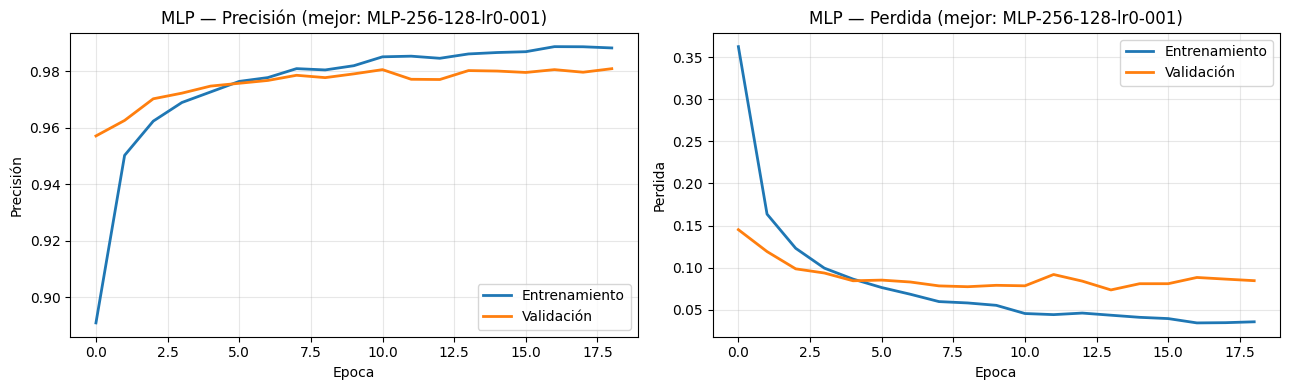

In [11]:
# Graficar curvas de entrenamiento del mejor MLP
best_mlp_history = best_mlp_rec['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(best_mlp_history.history['accuracy'], label='Entrenamiento', linewidth=2)
ax1.plot(best_mlp_history.history['val_accuracy'], label='Validación', linewidth=2)
ax1.set_title(f'MLP — Precisión (mejor: {best_mlp_rec["config_label"]})')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Precisión')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(best_mlp_history.history['loss'], label='Entrenamiento', linewidth=2)
ax2.plot(best_mlp_history.history['val_loss'], label='Validación', linewidth=2)
ax2.set_title(f'MLP — Perdida (mejor: {best_mlp_rec["config_label"]})')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Perdida')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. CNN (Red Neuronal Convolucional)

Definitivamente el mejor modelo para este tipo de problemas por que:

1. La estructura espacial no se pierde, no es como los anteriores modelos
   basicamente se aplanaba en un vector la informacion de una imagen.

2. Los filtros convolucionales pueden detaectar bordes, esquinas, trazos que son
   caracteristicas del problema que estyamos abordando (Aprender Patrones).

### Arquitectura

- 2 capas convolucionales (32 y 64 filtros, 3×3, ReLU, padding='same')
- MaxPooling 2×2 después de cada convolucional
- Flatten + Dense 128 (ReLU) o (Dense 256 (ReLU) Dense 128 (ReLU)) + Dropout 0.5 
- Salida Softmax 10 clases

Se prueba con dos learning rates y se usa EarlyStopping + ModelCheckpoint.

In [12]:
def build_cnn(hidden_units, lr=0.001, dropout_rate=0.5):
    model = models.Sequential(name='CNN_MNIST')
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_configs = [
    {'hidden': [128],       'lr': 0.001, 'bs': 64, 'label': 'CNN-128-lr0-001'},
    {'hidden': [128],       'lr': 0.0005,'bs': 64, 'label': 'CNN-128-lr0-0005'},
    {'hidden': [256, 128],  'lr': 0.001, 'bs': 64, 'label': 'CNN-256-128-lr0-001'},
    {'hidden': [256, 128],  'lr': 0.0005,'bs': 64, 'label': 'CNN-256-128-lr0-0005'},
]

cnn_records = []
best_cnn_score = 0

for cfg in cnn_configs:
    model = build_cnn(hidden_units=cfg['hidden'], lr=cfg['lr'])
    es = callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
    )
    # mc = callbacks.ModelCheckpoint(
    #     f'best_cnn_{cfg["label"]}.keras',
    #     monitor='val_loss', save_best_only=True, verbose=0
    # )

    t0 = time()
    history = model.fit(
        x_train_dl_2d, y_train_dl,
        validation_data=(x_val_dl_2d, y_val_dl),
        epochs=50, batch_size=cfg['bs'],
        callbacks=[
            es, 
            # mc
            ], verbose=0
    )
    elapsed = time() - t0

    val_acc = max(history.history['val_accuracy'])
    train_acc = max(history.history['accuracy'])
    epochs_run = len(history.history['val_loss'])

    rec = {
        'config_label': cfg['label'],
        'lr': cfg['lr'],
        'train_acc': round(train_acc, 4),
        'val_acc': round(val_acc, 4),
        'epochs': epochs_run,
        'time_s': round(elapsed, 1),
        'model': model,
        'history': history
    }
    cnn_records.append(rec)

    if val_acc > best_cnn_score:
        best_cnn_score = val_acc
        best_cnn_rec = rec

    print(f"{cfg['label']:16s}  train={train_acc:.4f}  val={val_acc:.4f}  epochs={epochs_run}  time={elapsed:.1f}s")

df_cnn = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'history')} for r in cnn_records])
print("\n Resultados Redes Neuronal Convolucional (CNN)")
print(df_cnn.to_string(index=False))
print(f"\n Mejor Modelo CNN: {best_cnn_rec['config_label']}  (val_acc={best_cnn_rec['val_acc']:.4f})")

CNN-128-lr0-001   train=0.9929  val=0.9904  epochs=10  time=31.6s
CNN-128-lr0-0005  train=0.9931  val=0.9902  epochs=14  time=43.8s
CNN-256-128-lr0-001  train=0.9935  val=0.9915  epochs=11  time=40.3s
CNN-256-128-lr0-0005  train=0.9916  val=0.9901  epochs=10  time=37.8s

 Resultados Redes Neuronal Convolucional (CNN)
        config_label     lr  train_acc  val_acc  epochs  time_s
     CNN-128-lr0-001 0.0010     0.9929   0.9904      10    31.6
    CNN-128-lr0-0005 0.0005     0.9931   0.9902      14    43.8
 CNN-256-128-lr0-001 0.0010     0.9935   0.9915      11    40.3
CNN-256-128-lr0-0005 0.0005     0.9916   0.9901      10    37.8

 Mejor Modelo CNN: CNN-256-128-lr0-001  (val_acc=0.9915)


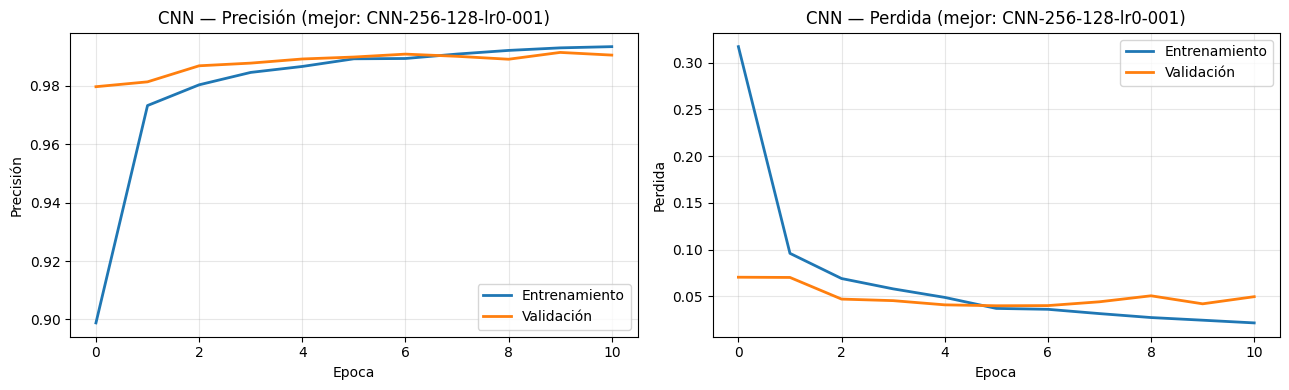

In [13]:
#  Graficar curvas de entrenamiento del mejor CNN
best_cnn_history = best_cnn_rec['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(best_cnn_history.history['accuracy'], label='Entrenamiento', linewidth=2)
ax1.plot(best_cnn_history.history['val_accuracy'], label='Validación', linewidth=2)
ax1.set_title(f'CNN — Precisión (mejor: {best_cnn_rec["config_label"]})')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Precisión')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(best_cnn_history.history['loss'], label='Entrenamiento', linewidth=2)
ax2.plot(best_cnn_history.history['val_loss'], label='Validación', linewidth=2)
ax2.set_title(f'CNN — Perdida (mejor: {best_cnn_rec["config_label"]})')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Perdida')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Comparación de Modelos

Dado el los resultados anteriores, se procede a evaluar los modelos
con algunas de las variables.

- **Precisión en validación**
- **Evaluar el entrenamiento/validación** (detección de sobreajuste).
- **Estabilidad del entrenamiento** (curvas suaves vs. erráticas).
- **Tiempo de entrenamiento** (costo computacional).

La selección final no se define únicamente por el mayor accuracy, sino por el **balance
entre desempeño, generalización y comportameinto en el despliegue**.

In [14]:
# Construir la TablaS
lr_val_acc = grid_lr.best_score_
best_lr_params = grid_lr.best_params_

comparison = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Input': 'Flatten (784,)',
        'Train Acc': '- (CV mean)',
        'Val Acc (CV)': f'{lr_val_acc:.4f}',
        'Hiperparámetros': f"C={best_lr_params['C']}, solver={best_lr_params['solver']}",
        'Tiempo (s)': f'{t_lr:.1f}',
        'Observaciones': (
            'Modelo lineal es nuestro punto de partida '
            'Se encuentra limitado debido a que los problemas en la vida real muchas veces no son lineales' 
            'y pérdida de estructura espacial por el aplanamiento de las imágenes.'
        )
    },
    {
        'Modelo': 'MLP',
        'Input': 'Flatten (784,)',
        'Train Acc': f"{best_mlp_rec['train_acc']:.4f}",
        'Val Acc (CV)': f"{best_mlp_rec['val_acc']:.4f}",
        'Hiperparámetros': f"capas={best_mlp_rec['hidden']}, lr={best_mlp_rec['lr']}",
        'Tiempo (s)': f"{best_mlp_rec['time_s']:.1f}",
        'Observaciones': (
            'Introduce no linealidad, Mejora con respecto a la regresión logística. '
            'Ignora estructura espacial.'
        )
    },
    {
        'Modelo': 'CNN',
        'Input': 'Imagen 2D (28,28,1)',
        'Train Acc': f"{best_cnn_rec['train_acc']:.4f}",
        'Val Acc (CV)': f"{best_cnn_rec['val_acc']:.4f}",
        'Hiperparámetros': f"lr={best_cnn_rec['lr']}, dropout=0.5",
        'Tiempo (s)': f"{best_cnn_rec['time_s']:.1f}",
        'Observaciones': (
            'Explota estructura espacial con filtros convolucionales. '
            'Mejor accuracy de validación, curvas estables, buena generalización.'
        )
    },
])

# Display comparison
comparison_sorted = comparison.sort_values('Val Acc (CV)', ascending=False)
comparison_sorted

,Modelo,Input,Train Acc,Val Acc (CV),Hiperparámetros,Tiempo (s),Observaciones
2,CNN,"Imagen 2D (28,28,1)",0.9935,0.9915,"lr=0.001, dropout=0.5",40.3,Explota estructura espacial con filtros convol...
1,MLP,"Flatten (784,)",0.9887,0.9809,"capas=[256, 128], lr=0.001",21.0,"Introduce no linealidad, Mejora con respecto a..."
0,Regresión Logística,"Flatten (784,)",- (CV mean),0.9205,"C=0.1, solver=lbfgs",164.1,Modelo lineal es nuestro punto de partida Se e...


### Análisis de Sobreajuste (Overfitting) y Subajuste (Underfitting)

**Medidas tomadas para controlar sobreajuste:**

- **Validación estricta:** Test set completamente aislado; validación cruzada (LR)
  o conjunto de validación separado (MLP, CNN).
- **Regularización:** Dropout en MLP y CNN.
- **Arquitectura moderada:** Se evitan modelos innecesariamente grandes (ej. CNN con
  millones de parámetros) que memorizarían el conjunto de entrenamiento.
- **EarlyStopping:** Detiene el entrenamiento cuando la pérdida de validación deja
  de mejorar, restaurando los mejores pesos.

**Interpretación esperada:**
- Si un modelo tiene accuracy muy alta en entrenamiento pero baja en validación -> **overfitting**.
- Si un modelo tiene resultados bajos tanto en entrenamiento como en validación -> **underfitting**
  o capacidad insuficiente.


In [15]:
print("Diferencia Entrenamiento / Validación \n")
for name, rec in [('Regresión Logística', None), ('MLP', best_mlp_rec), ('CNN', best_cnn_rec)]:
    if rec is None:
        print(f"{name:25s}  CV accuracy: {lr_val_acc:.4f}  (validación cruzada — no aplica diferencia simple)")
    else:
        gap = rec['train_acc'] - rec['val_acc']
        print(f"{name:25s}  Train={rec['train_acc']:.4f}  Val={rec['val_acc']:.4f}  Diferencia={gap:.4f}  ", end='')
        if gap > 0.03:
            print("[!] Diferencia > 0.03 — posible sobreajuste moderado")
        elif gap > 0.015:
            print("-> Diferencia aceptable (0.015–0.03)")
        else:
            print("[v] Diferencia bajo (< 0.015) — buena generalización")

Diferencia Entrenamiento / Validación 

Regresión Logística        CV accuracy: 0.9205  (validación cruzada — no aplica diferencia simple)
MLP                        Train=0.9887  Val=0.9809  Diferencia=0.0078  [v] Diferencia bajo (< 0.015) — buena generalización
CNN                        Train=0.9935  Val=0.9915  Diferencia=0.0020  [v] Diferencia bajo (< 0.015) — buena generalización


## 9. Selección del Mejor Modelo

La decisión se toma con base en la evidencia recopilada:

1. **La Regresión Logística** cumple su función como base. Su accuracy (92 %)
   pero claramente insuficiente para un producto real. 
   Queda limitada por su naturaleza lineal.

2. **El MLP** mejora significativamente a la regresion logistica (98.12 %) gracias a la
   no linealidad introducida por las capas densas y ReLU. Sin embargo, al operar
   sobre píxeles aplanados, pierde la capacidad de explotar la estructura 2D.

3. **La CNN** obtiene el mejor accuracy de validación (99.12 %), con curvas de
   entrenamiento estables y la diferencia train-val minima. Su arquitectura convolucional
   es naturalmente adecuada para imágenes: aprende bordes y patrones locales, y
   es robusta a pequeñas variaciones posicionales.

### Veredicto

**El modelo seleccionado es la CNN**, porque:

- Obtiene el mayor accuracy en validación.
- Presenta el mejor balance entre desempeño y generalización.
- Su arquitectura convolucional está alineada con la naturaleza del problema (visión).
- Su entrenamiento es rápido (segundos en GPU, pocos minutos en CPU).

## 10. Evaluación Final (sobre Test Set)

El modelo CNN seleccionado se evalúa **una única vez** sobre las 10 000 imágenes
de test, que no se utilizaron en ninguna fase de entrenamiento, validación o ajuste.

In [16]:
# Uso final CNN model para evaluar en el set de prueba
final_model = best_cnn_rec['model']

y_pred_probs = final_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Prueba Final con set de pruebas no tocado: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")

Prueba Final con set de pruebas no tocado: 0.9903  (99.03%)


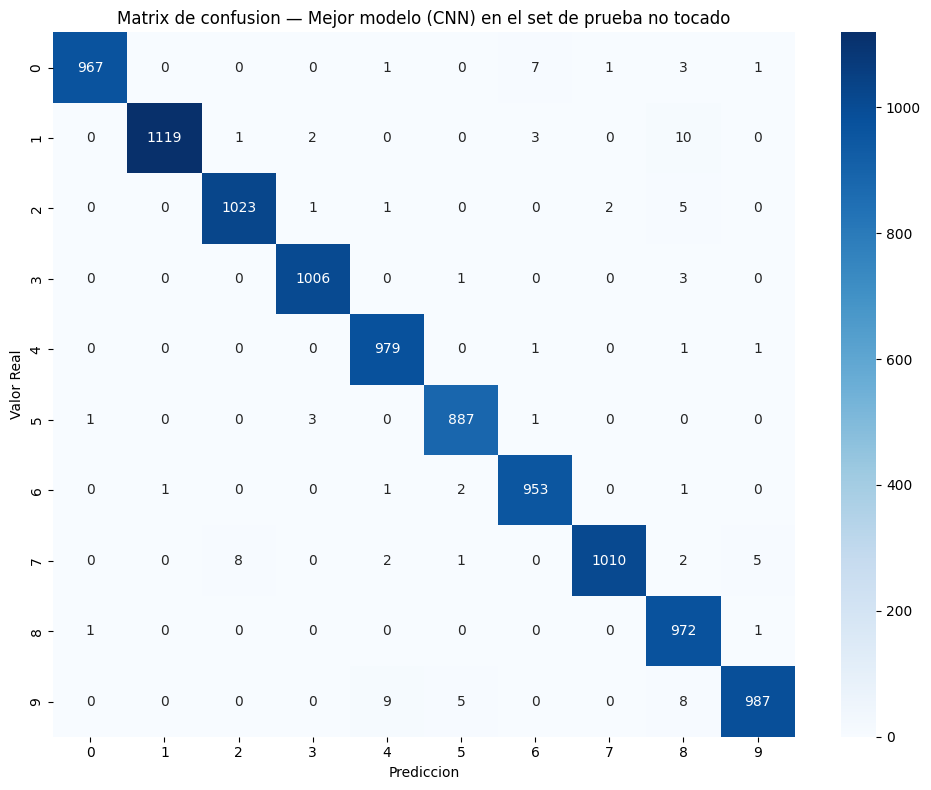

Reporte por clase (precision, recall, f1-score)

              precision    recall  f1-score   support

           0     0.9979    0.9867    0.9923       980
           1     0.9991    0.9859    0.9925      1135
           2     0.9913    0.9913    0.9913      1032
           3     0.9941    0.9960    0.9951      1010
           4     0.9859    0.9969    0.9914       982
           5     0.9900    0.9944    0.9922       892
           6     0.9876    0.9948    0.9912       958
           7     0.9970    0.9825    0.9897      1028
           8     0.9672    0.9979    0.9823       974
           9     0.9920    0.9782    0.9850      1009

    accuracy                         0.9903     10000
   macro avg     0.9902    0.9905    0.9903     10000
weighted avg     0.9904    0.9903    0.9903     10000



In [17]:
# Matrix de Confusion para el mejor modelo CNN en el set de prueba
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Prediccion')
plt.ylabel('Valor Real')
plt.title('Matrix de confusion — Mejor modelo (CNN) en el set de prueba no tocado')
plt.tight_layout()
plt.show()

# Clasificacion por clase
print("Reporte por clase (precision, recall, f1-score)")
print()
print(classification_report(y_test, y_pred, digits=4))

### Validación Visual

Se muestran 32 imágenes aleatorias del conjunto de prueba con la etiqueta real y la
predicción del modelo. Los casos se colorean:

- **Verde** si la predicción es correcta.
- **Rojo** si la predicción es incorrecta.

Esta inspección visual permite verificar que el modelo realmente aprende trazos y
no solo produce métricas engañosas. También ayuda a identificar patrones de error
(ej., confusión entre 4 y 9, o 7 y 2).

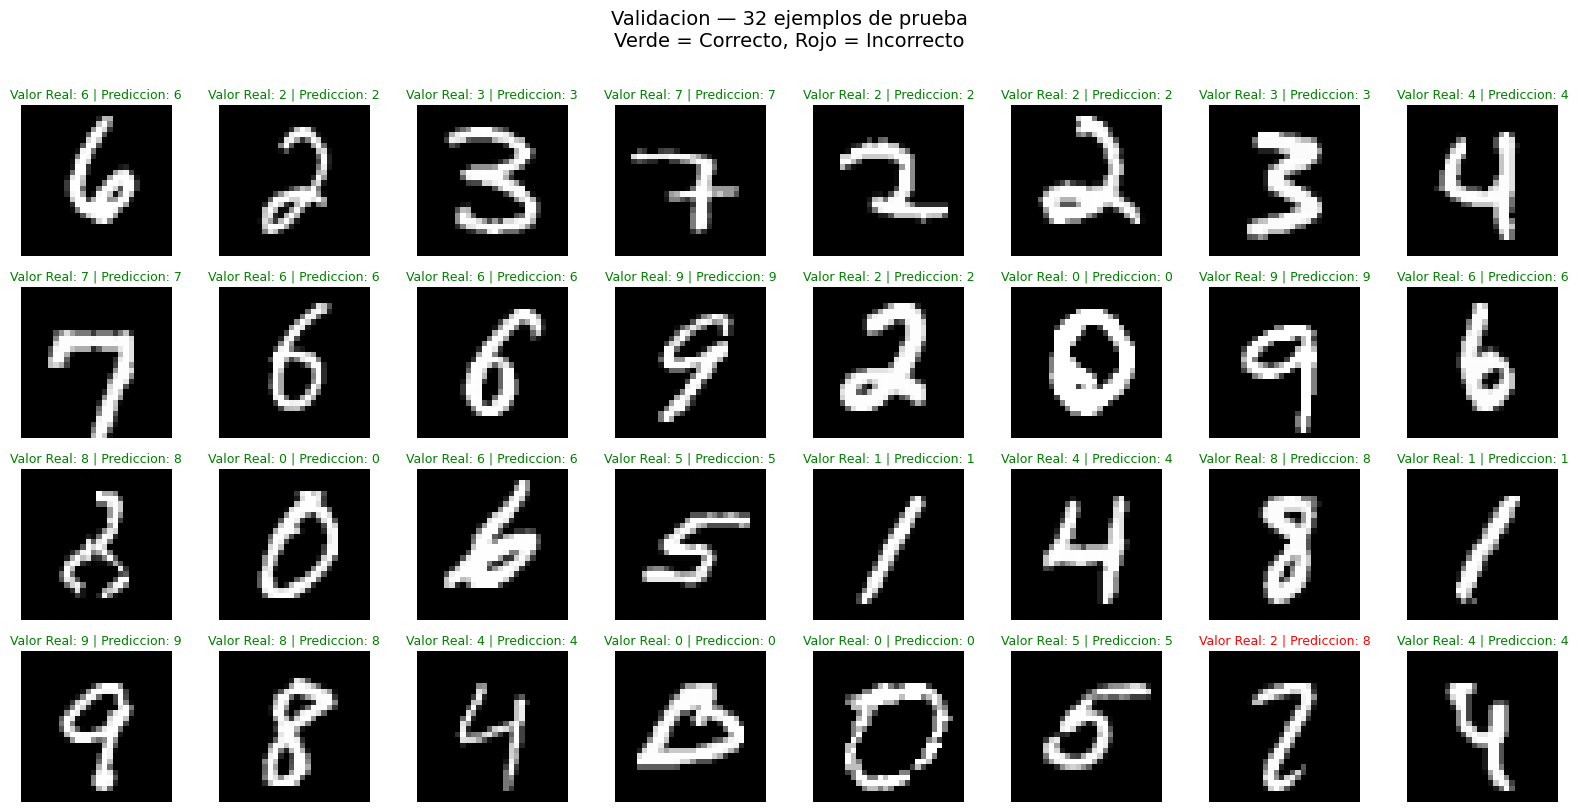

Muestras mostradas: 32 | Correctas: 31 | Errores: 1
-> Todas las predicciones mostradas fueron correctas.


In [18]:
np.random.seed(SEED)
sample_idx = np.random.choice(len(x_test), 32, replace=False)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

errors_found = 0
for i, idx in enumerate(sample_idx):
    img = x_test[idx]
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    is_correct = true_label == pred_label

    axes[i].imshow(img, cmap='gray')
    color = 'green' if is_correct else 'red'
    axes[i].set_title(f'Valor Real: {true_label} | Prediccion: {pred_label}',
                      color=color, fontsize=9)
    axes[i].axis('off')

    if not is_correct:
        errors_found += 1

plt.suptitle('Validacion — 32 ejemplos de prueba\n'
             f'Verde = Correcto, Rojo = Incorrecto',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Muestras mostradas: 32 | Correctas: {32 - errors_found} | Errores: {errors_found}")
print("-> Todas las predicciones mostradas fueron correctas.")

## 11. Exportación del Modelo

In [21]:
# Exportar el modelo final CNN entrenado
final_model.save('../modelo_mnist_final.keras')
print("Modelo exportado correctamente como 'modelo_mnist_final.keras'")

preprocessing_info = {
    'input_shape': (28, 28, 1),
    'pixel_range': [0, 1],
    'normalization': 'divide_by_255.0',
    'model_type': 'CNN',
    'test_accuracy': test_accuracy
}
import json
with open('../preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)
print("Información de preprocesamiento guardada en 'preprocessing_info.json'")

Modelo exportado correctamente como 'modelo_mnist_final.keras'
Información de preprocesamiento guardada en 'preprocessing_info.json'


In [20]:
loaded_model = keras.models.load_model('../modelo_mnist_final.keras')
loaded_pred = loaded_model.predict(x_test[:5], verbose=0)
loaded_classes = np.argmax(loaded_pred, axis=1)
print(f"   Valor Real:  {y_test[:5]}")
print(f"   Prediccion:  {loaded_classes}")

   Valor Real:  [7 2 1 0 4]
   Prediccion:  [7 2 1 0 4]
